In [2]:
pip install shap

  Using cached shap-0.51.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (25 kB)
  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.47.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.0 kB)
Using cached shap-0.51.0-cp312-cp312-macosx_11_0_arm64.whl (562 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 1.8 MB/s  0:00:20 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.4 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
ERROR: pip's dependency resolver does 

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load
X = pd.read_csv('pdac_features_X.csv')
y = pd.read_csv('pdac_labels_y.csv').squeeze()  # squeeze to Series

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: {y.sum()} success, {(1-y).sum()} failure")
print(f"\nAny NaN in X: {X.isnull().any().any()}")
print(f"All numeric: {X.select_dtypes(exclude=[np.number]).shape[1] == 0}")

X shape: (107, 63)
y shape: (107,)
Class balance: 47 success, 60 failure

Any NaN in X: False
All numeric: True


In [4]:
# Stratified K-Fold — essential with small datasets
# Stratified means each fold has the same class ratio as the full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression baseline
# Need to scale features first — LR is sensitive to feature magnitude
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='roc_auc')

print("=== Logistic Regression (baseline) ===")
print(f"AUC per fold: {lr_scores.round(3)}")
print(f"Mean AUC: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")

=== Logistic Regression (baseline) ===
AUC per fold: [0.608 0.775 0.463 0.63  0.583]
Mean AUC: 0.612 ± 0.100


In [5]:
# Random Forest — no scaling needed, handles mixed features well
rf = RandomForestClassifier(
    n_estimators=500,      # number of trees
    max_depth=4,           # shallow trees — prevents overfitting on small dataset
    min_samples_leaf=5,    # each leaf needs at least 5 samples
    class_weight='balanced', # compensates for class imbalance
    random_state=42
)

rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print("=== Random Forest ===")
print(f"AUC per fold: {rf_scores.round(3)}")
print(f"Mean AUC: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

=== Random Forest ===
AUC per fold: [0.6   0.617 0.769 0.722 0.556]
Mean AUC: 0.653 ± 0.080


In [6]:
print("\n=== Model comparison ===")
print(f"Logistic Regression: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")
print(f"Random Forest:       {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"\nBaseline (random):   0.500")
print(f"Good model:          > 0.650")


=== Model comparison ===
Logistic Regression: 0.612 ± 0.100
Random Forest:       0.653 ± 0.080

Baseline (random):   0.500
Good model:          > 0.650


<class 'numpy.ndarray'>
(107, 63, 2)
shap_success shape: (107, 63)
X shape: (107, 63)


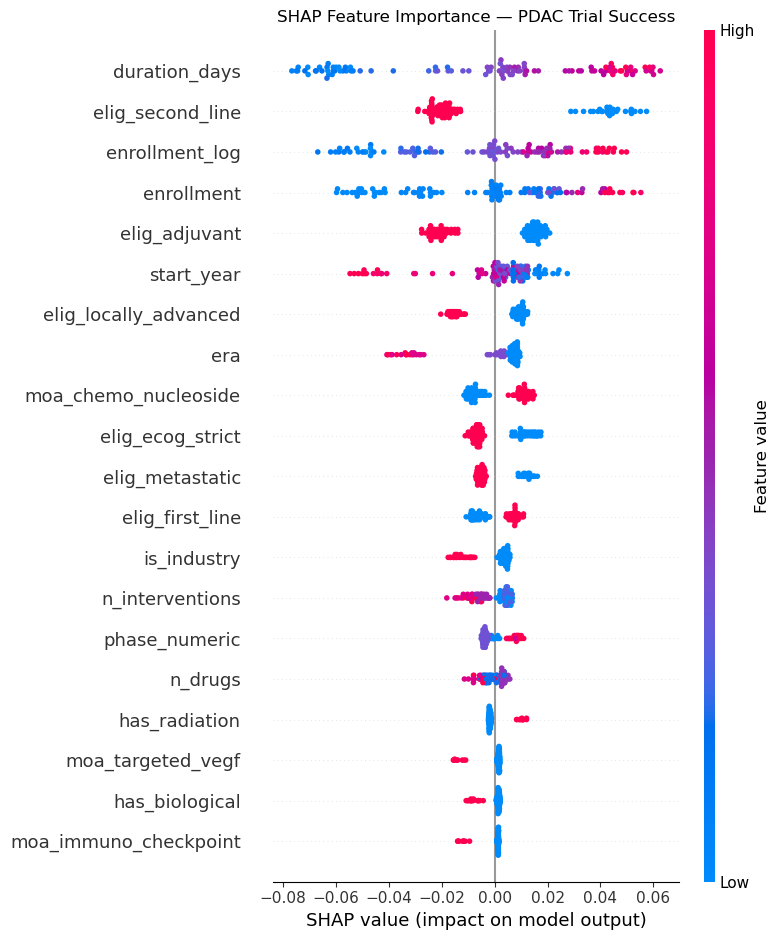

In [10]:
# Check what shape shap_values actually is
print(type(shap_values))
print(np.array(shap_values).shape)

# Fix — newer SHAP returns shape (n_classes, n_samples, n_features)
# We want class 1 (SUCCESS)
if isinstance(shap_values, list):
    shap_success = shap_values[1]  # old format
else:
    shap_success = shap_values[:, :, 1]  # new format

print(f"shap_success shape: {shap_success.shape}")
print(f"X shape: {X.shape}")

# Now plot
plt.figure()
shap.summary_plot(
    shap_success,
    X,
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance — PDAC Trial Success")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

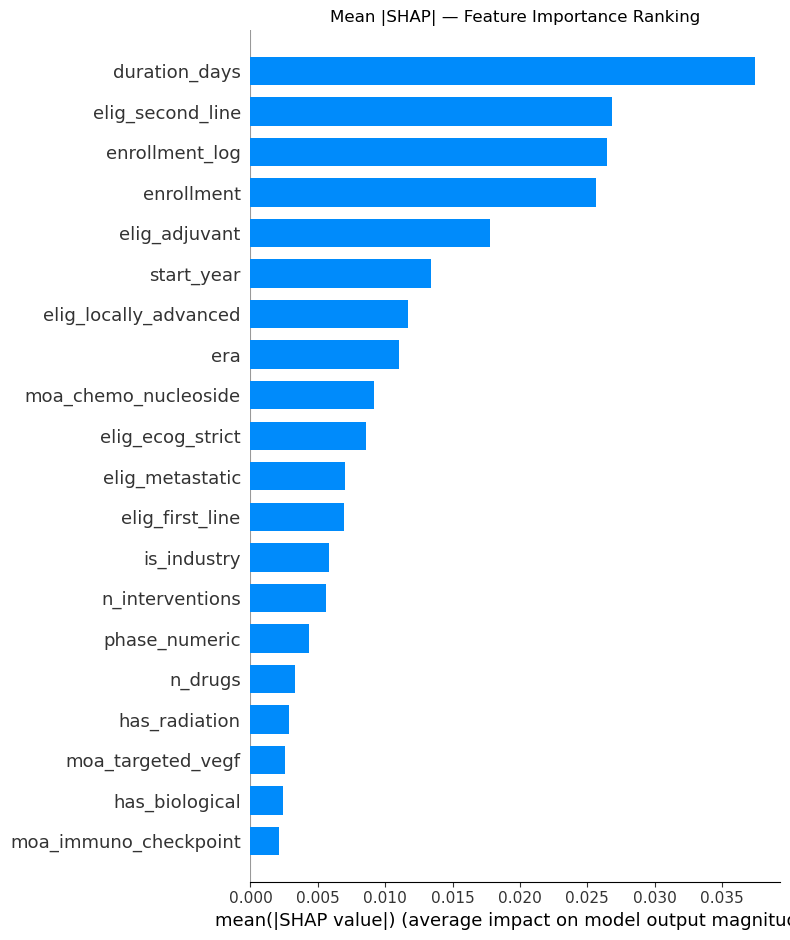

In [11]:
# Mean absolute SHAP — overall feature importance ranking
shap.summary_plot(
    shap_success,
    X,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("Mean |SHAP| — Feature Importance Ranking")
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
pip install umap-learn

  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import umap

reducer = umap.UMAP(
    n_neighbors=10,    # small dataset — use smaller neighborhood
    min_dist=0.3,
    random_state=42
)

embedding = reducer.fit_transform(X)

# Plot colored by outcome
plt.figure(figsize=(9, 7))
colors = ['#e74c3c' if label == 1 else '#3498db' for label in y]
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=colors, alpha=0.7, s=80, edgecolors='white', linewidths=0.5
)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='SUCCESS'),
    Patch(facecolor='#3498db', label='FAILURE')
]
plt.legend(handles=legend_elements, fontsize=12)
plt.title("UMAP — PDAC Trial Space\ncolored by outcome", fontsize=13)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.savefig('umap_outcome.png', dpi=150, bbox_inches='tight')
plt.show()